In [1]:
'''
The simulations with synthetic data to test the behavior of MOS in different data structure.
'''

import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Print df_degfieldd without truncation
pd.set_option('display.max_rows', None)


In [2]:
def compute_mci_hajime(A, At=None, mci_init=None, iter=250, output_other_side=False):
    M, N = A.shape
    if mci_init is None:
        assert np.all(np.isin(A,[0,1])), "A must be binary matrix if mci_init is not provided."
        mci_init = A.sum(axis=1)
    mci = mci_init.copy().values.reshape([-1,1])
    if At is None:
        At = A.T
    Aw = A/np.sum(A,axis=1).values.reshape(M,1)
    Atw = At/np.sum(At,axis=1).values.reshape(N,1)

    result_mci = pd.DataFrame(index=A.index)
    result_mci[f'iter_{0}'] = mci
    result_oci = pd.DataFrame(index=A.columns)
    for i in range(iter):
        oci = np.dot(Atw,mci)
        mci = np.dot(Aw,oci)
        # oci = (oci - oci.mean())/oci.std()
        # mci = (mci - mci.mean())/mci.std()
        oci = (oci - oci.min())/(oci.max()-oci.min()) + 1e-5
        mci = (mci - mci.min())/(mci.max()-mci.min()) + 1e-5
        result_mci[f'iter_{i+1}'] = mci
        result_oci[f'iter_{i+1}'] = oci
    if output_other_side:
        return result_mci, result_oci
    else:
        return result_mci


def binarize_by_rca(df_adj):
    # Construct the binary matrix.
    binarize_method='rca'
    major_share = (df_adj.T/df_adj.sum(axis=1) ).T #Share of an occupation within a major
    if binarize_method == 'rca':
        binarize_threshold = 1.
        occupation_share = df_adj.sum(axis=0)/df_adj.sum().sum()
        rca = major_share/occupation_share
        major_occupation_matrix = (rca>binarize_threshold).astype(int)

    return major_occupation_matrix

def binarize_by_rca_external_occ_ratio(df_adj, df_occ_global):
    # Construct the binary matrix assuming the occupation ratio (denominator) is given.
    binarize_method='rca'
    major_share = (df_adj.T/df_adj.sum(axis=1) ).T #Share of an occupation within a major
    if binarize_method == 'rca':
        binarize_threshold = 1.
        occupation_share = df_occ_global/df_occ_global.sum() #df_adj.sum(axis=0)/df_adj.sum().sum()
        rca = major_share/occupation_share
        major_occupation_matrix = (rca>binarize_threshold).astype(int)

    return major_occupation_matrix



In [ ]:
df_degfield = pd.read_csv('../data/processed_data/acs/degfield_mapping.csv', index_col=0)
df_degfieldd = pd.read_csv('../data/processed_data/acs/degfieldd_mapping.csv', index_col=0)
# 24 is engineering. 37	mathematics and statistics

major_ref_top_degfield = 21 #computer and information sciences
major_ref_bottom_degfield = 60 #fine arts
major_ref_top_degfieldd = 2102 #computer science
major_ref_bottom_degfieldd = 6000 #drama and theater arts

iterations = 25
binarize_method = 'rca'

soc_level = 2
major_var = 'degfieldd'
major_name = df_degfield if major_var == 'degfield' else df_degfieldd
major_name.index.name = 'major'
if binarize_method == 'rca':
    binarize_threshold = 1.

# Read data
adj_matrix = pd.read_csv(f'../data/processed_data/acs/adj_{major_var}_soc{soc_level}.csv',index_col=0)




In [4]:
temp = pd.read_csv(f'../data/processed_data/acs/adj_degfield_soc2.csv',index_col=0)
temp.sum(axis=1)

major
11      8999
13      5801
14      5069
15      2072
19     40611
20      1996
21     30844
22      1108
23     47628
24     52314
25      5427
26      4010
29      5379
32      1060
33     15651
34      8942
36     21117
37      5120
40      5351
41     11067
48      3114
49      3202
50     11624
51       344
52     27071
53     20201
54      6429
55     43403
56      3152
57       317
59      2409
60     38178
61     44092
62    157804
64     10830
dtype: int64

SOC2
degfield
2102
30844
Using the original national ratio of occupations for denominator of RCA


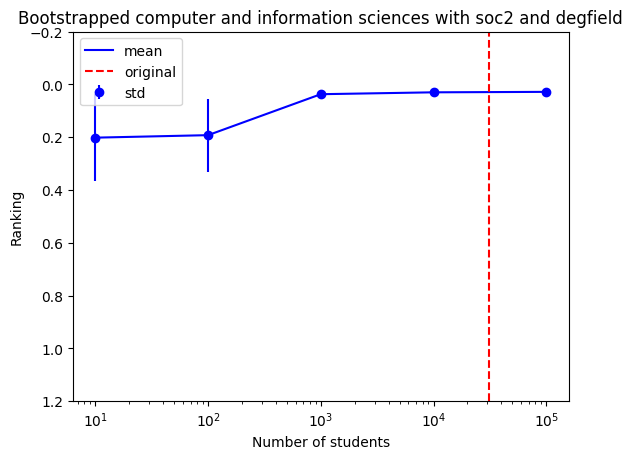

2300
47628
Using the original national ratio of occupations for denominator of RCA


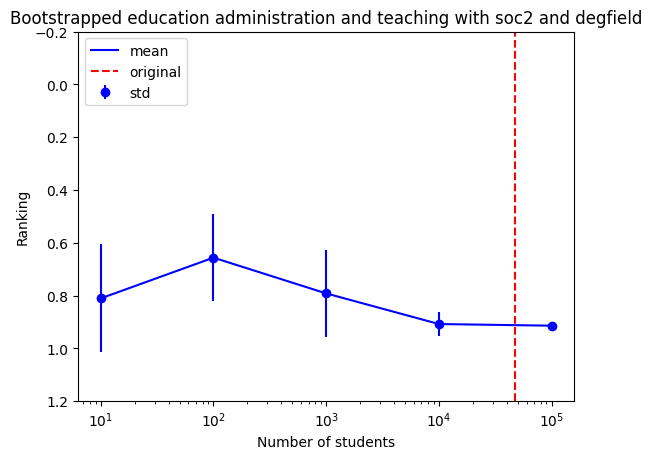

3702
5120
Using the original national ratio of occupations for denominator of RCA


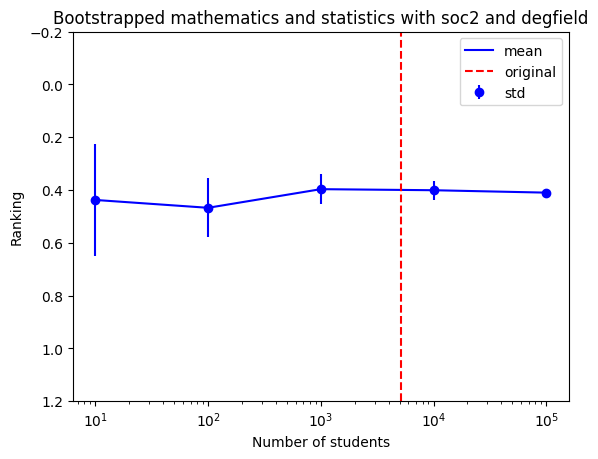

6107
44092
Using the original national ratio of occupations for denominator of RCA


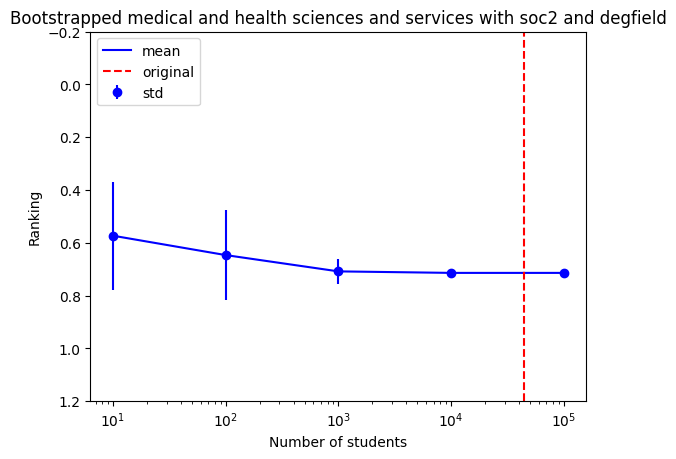

6201
157804
Using the original national ratio of occupations for denominator of RCA


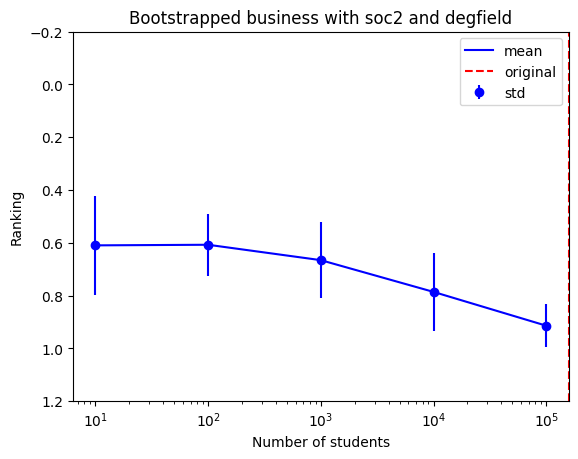

degfieldd
2102
18037
Using the original national ratio of occupations for denominator of RCA


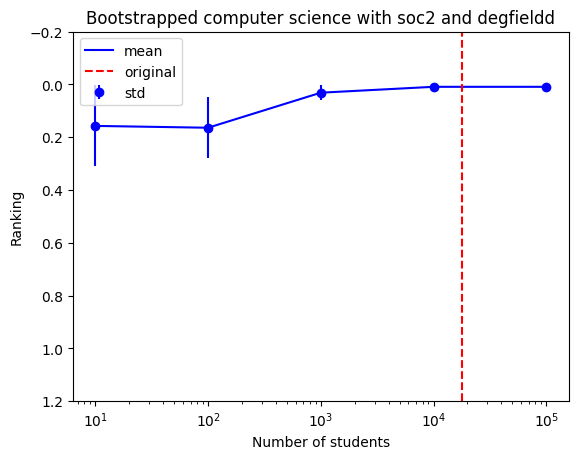

2300
11795
Using the original national ratio of occupations for denominator of RCA


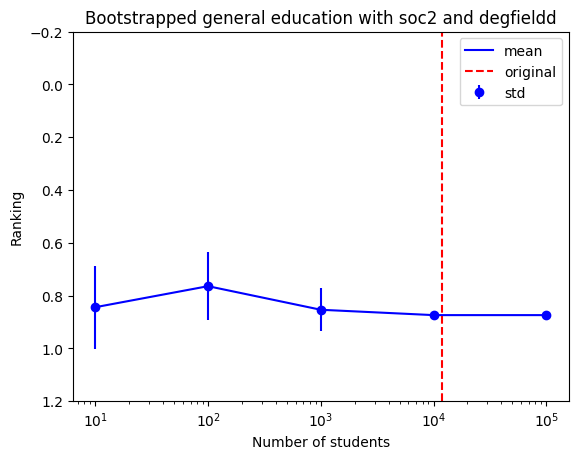

3702
349
Using the original national ratio of occupations for denominator of RCA


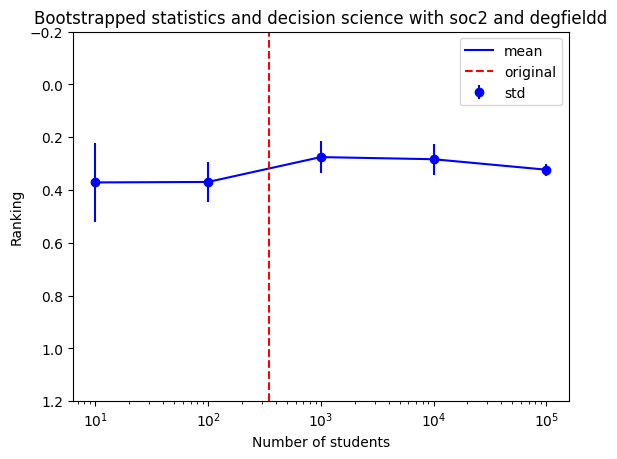

6107
28324
Using the original national ratio of occupations for denominator of RCA


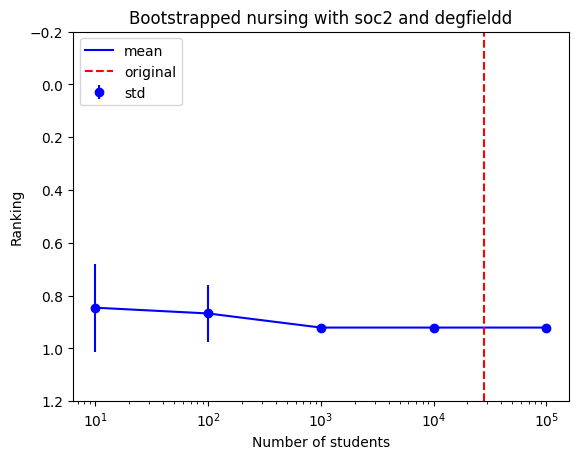

6201
20610
Using the original national ratio of occupations for denominator of RCA


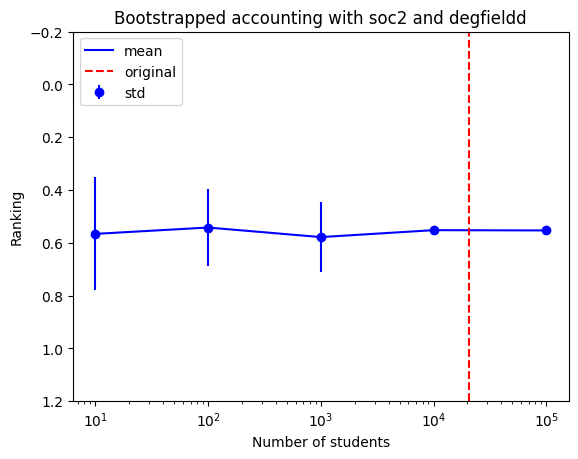

SOC4
degfield
2102
30840
Using the original national ratio of occupations for denominator of RCA


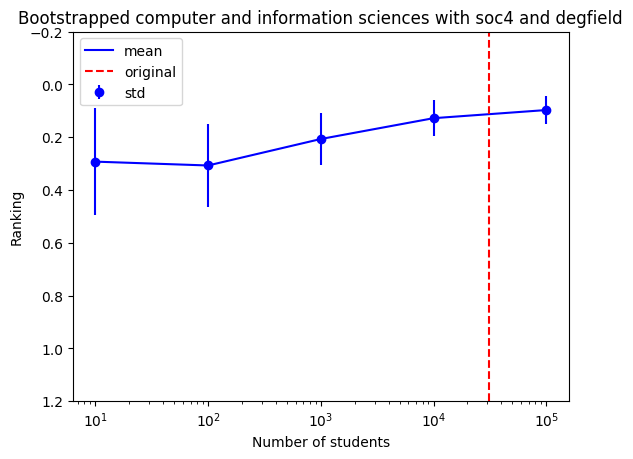

2300
47624
Using the original national ratio of occupations for denominator of RCA


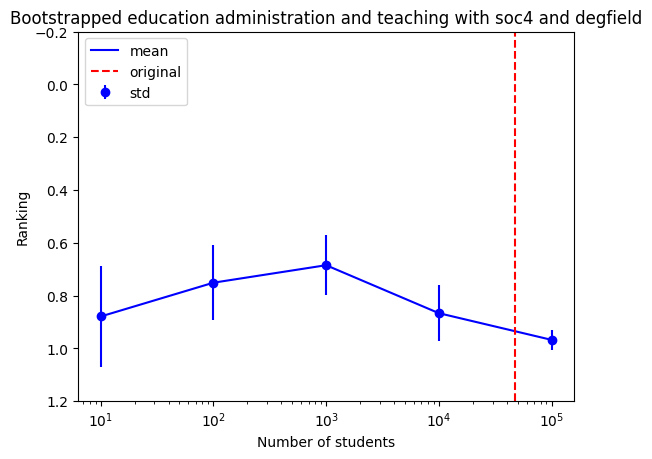

3702
5120
Using the original national ratio of occupations for denominator of RCA


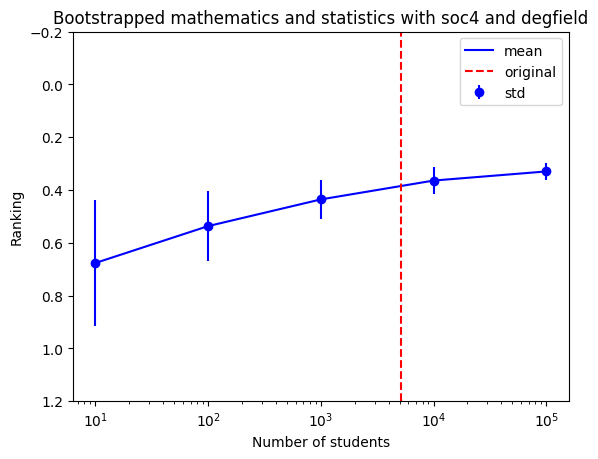

6107
44090
Using the original national ratio of occupations for denominator of RCA


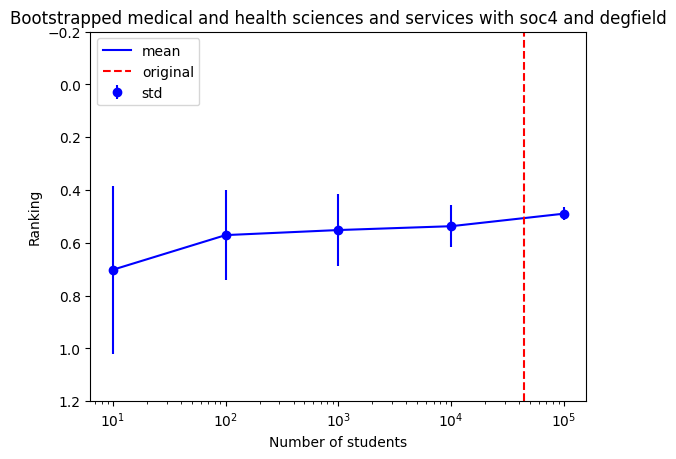

6201
157779
Using the original national ratio of occupations for denominator of RCA


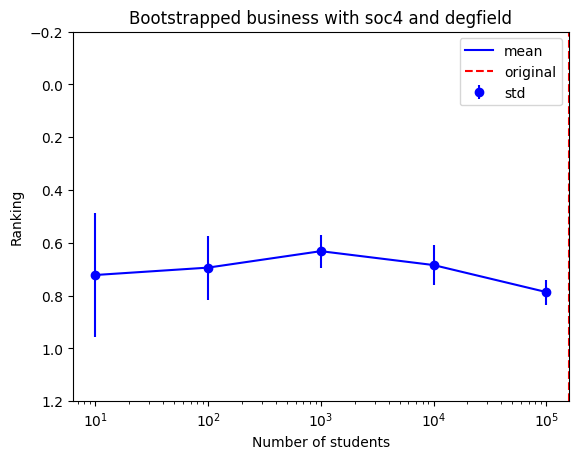

degfieldd
2102
18036
Using the original national ratio of occupations for denominator of RCA


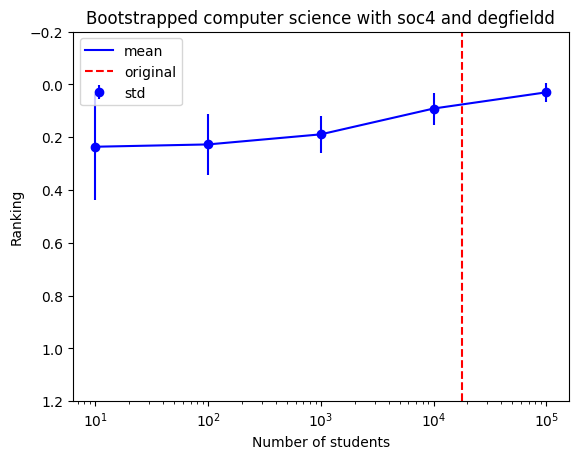

2300
11795
Using the original national ratio of occupations for denominator of RCA


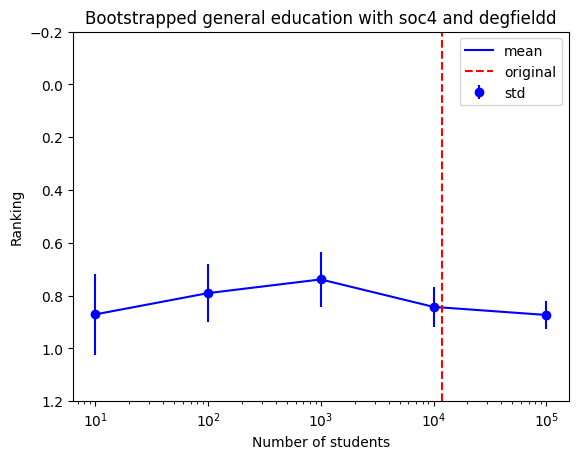

3702
349
Using the original national ratio of occupations for denominator of RCA


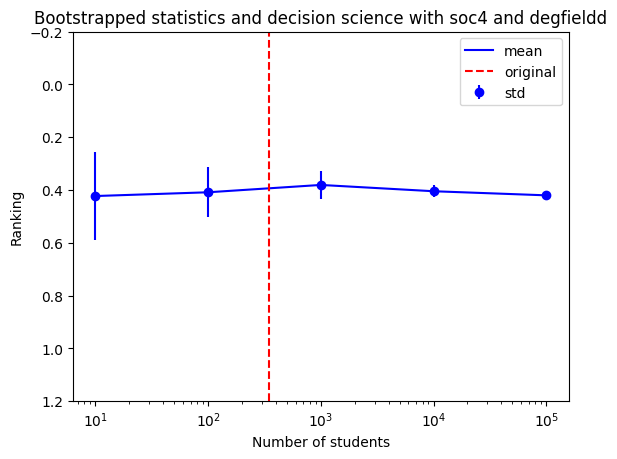

6107
28323
Using the original national ratio of occupations for denominator of RCA


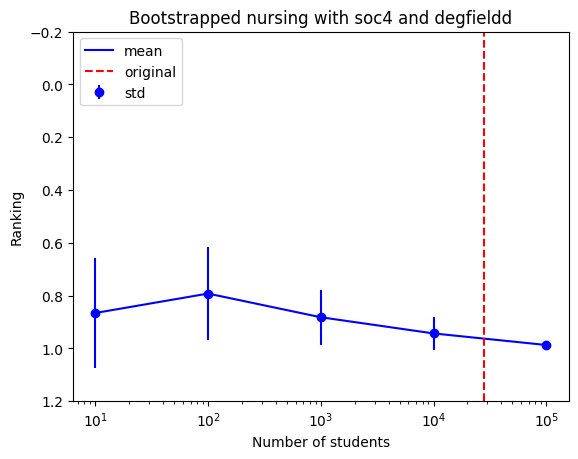

6201
20607
Using the original national ratio of occupations for denominator of RCA


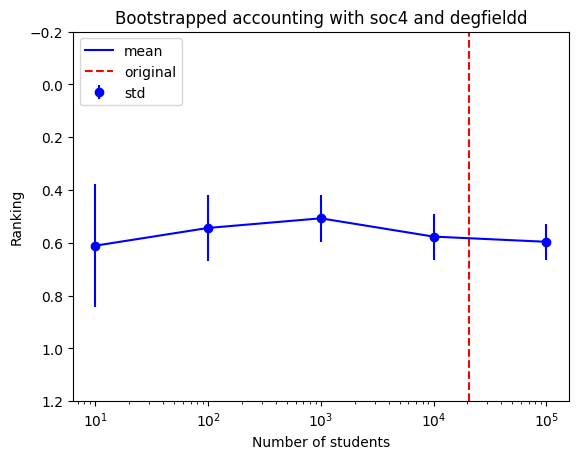

In [5]:

for soc_level in [2,4]:
    print(f'SOC{soc_level}')
    for major_var in ['degfield','degfieldd']:
        print(major_var)
        for target_major in [2102, 2300, 3702,6107,6201]:#
            print(target_major) 
            '''
            2102: computer science
            2300: general education
            3702: statistics and decision science
            6107: nursing
            6201: accounting
            '''
            major_i = target_major if major_var == 'degfieldd' else int(str(target_major)[:2])            

            major_name = df_degfield if major_var == 'degfield' else df_degfieldd
            major_name.index.name = 'major'
            adj_matrix = pd.read_csv(f'../data/processed_data/acs/adj_{major_var}_soc{soc_level}.csv',index_col=0)


            major_i_occ_ratio = adj_matrix.loc[major_i]/adj_matrix.loc[major_i].sum()
            major_i_original_num = adj_matrix.loc[major_i].sum()
            print(major_i_original_num)

            print('Using the original national ratio of occupations for denominator of RCA')
            occupation_share_original = adj_matrix.sum(axis=0)/adj_matrix.sum().sum()
            binary_matrix = binarize_by_rca_external_occ_ratio(adj_matrix,occupation_share_original)

            mci_original = compute_mci_hajime(binary_matrix, iter=iterations)
            ranking_original = mci_original.iloc[:,-1].rank(ascending=True)


            major_i_ranking_iter = pd.DataFrame()
            major_i_sum_rca = pd.DataFrame()
            major_i_mci =  pd.DataFrame()

            for n in [10,100,1000,10000,100000]:
                major_i_rankings_ = []
                major_i_rca_ = []
                major_i_mci_ = []
                for i in range(100):
                    ranking_df = pd.DataFrame(index=adj_matrix.index)

                    simulated_outcome = np.random.choice(adj_matrix.columns,p=major_i_occ_ratio, size=n)
                    count = np.unique( simulated_outcome,return_counts=True)
                    count = pd.Series(count[1],index=count[0])

                    # Replace adj_matrix_simulation.loc[major_i] with count
                    adj_matrix_simulation = adj_matrix.copy()
                    adj_matrix_simulation.loc[major_i] = count

                    # binary_matrix = binarize_by_rca(adj_matrix_simulation)
                    ''' 
                    Using the original national ratio of occupations for denominator of RCA
                    '''
                    binary_matrix = binarize_by_rca_external_occ_ratio(adj_matrix_simulation,occupation_share_original)
                    mci_b_H = compute_mci_hajime(binary_matrix, iter=iterations)
                    ranking = mci_b_H.iloc[:,-1].rank(ascending=True)

                    # Adjust the direction
                    major_ref_top = major_ref_top_degfieldd if major_var == 'degfieldd' else major_ref_top_degfield
                    major_ref_bottom = major_ref_bottom_degfieldd if major_var == 'degfieldd' else major_ref_bottom_degfield
                    if ranking[major_ref_top]>ranking[major_ref_bottom]:
                        mci_b_H = -mci_b_H
                        ranking = mci_b_H.iloc[:,-1].rank(ascending=True)


                    major_i_rankings_.append(ranking[major_i])
                    major_i_rca_.append(binary_matrix.loc[major_i].sum())
                    major_i_mci_.append(mci_b_H.iloc[:,-1].loc[major_i])
                major_i_ranking_iter[n] = pd.Series(major_i_rankings_).describe()
                major_i_sum_rca[n] = pd.Series(major_i_rca_).describe()
                major_i_mci[n] = pd.Series(major_i_mci_).describe()



            n_effective_majors = adj_matrix.shape[0]
            # Plot engineer_ranking_iter across n
            fig, ax = plt.subplots()
            ax.plot(major_i_ranking_iter.loc['mean']/n_effective_majors, label='mean',color='blue')
            ## Show std as error bar
            ax.errorbar(major_i_ranking_iter.columns, major_i_ranking_iter.loc['mean']/n_effective_majors, yerr=major_i_ranking_iter.loc['std']/n_effective_majors, fmt='o', label='std',color='blue')
            ax.set_xscale('log')
            #dashed vertical line for the actual number 
            ax.axvline(major_i_original_num, color='red', linestyle='--', label='original')
            ax.set_title(f'Bootstrapped {major_name.loc[major_i].values[0]} with soc{soc_level} and {major_var}')
            
            ax.set_xlabel('Number of students')
            ax.set_ylabel('Ranking')

            # Flip y-axis
            ax.invert_yaxis()
            # Fix y-axis in 0-1
            ax.set_ylim(1.2,-.2)


            # Save fig
            plt.legend()
            plt.savefig(f'../results_JHR_revision2/bootstrapped_{major_name.loc[major_i].values[0].replace(" ","_")}_soc{soc_level}_{major_var}_ranking_fixed_occ_ratio.pdf')

            plt.show()
